In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib
import os


The cell above  is where I imported all of the    that i would need to train the model effectively.

In [1]:
df = pd.read_csv("C:\Users\sadak\OneDrive\Desktop\CapstoneProject-\data\inventory_final_capstone.csv")
# Preview data
df.head()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (296188172.py, line 1)

In [8]:
X = df.drop(columns=["restocked", "product_name", "category"])
y = df["restocked"]

print("Features:")
print(X.columns)

Features:
Index(['product_id', 'price', 'stock_level', 'daily_demand',
       'supplier_lead_time', 'reorder_point', 'is_weekend', 'units_sold'],
      dtype='str')


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 2000
Testing size: 500


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test)

print("Model Evaluation:\n")
print(classification_report(y_test, y_pred))

Model Evaluation:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       442
           1       0.91      0.90      0.90        58

    accuracy                           0.98       500
   macro avg       0.95      0.94      0.95       500
weighted avg       0.98      0.98      0.98       500



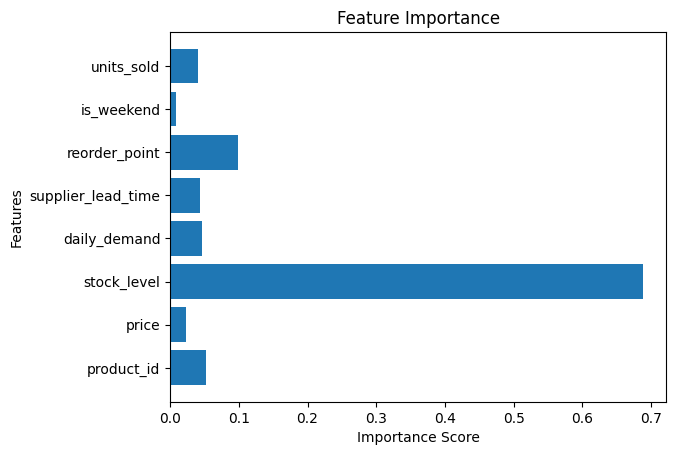

In [14]:
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
features = X.columns

plt.barh(features, feature_importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [15]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/inventory_model.pkl")

print("Model saved!")

Model saved!
